# 03 - Fine-tuning con LoRA: experimentacion y modelo final

Afina `Qwen/Qwen3-4B-Instruct-2507` para que genere preguntas de opcion multiple
en espanol a partir de fragmentos medicos en ingles.

El notebook **ejecuta la experimentacion completa**, no muestra resultados
pegados:

| Seccion | Que hace | Tiempo |
|---|---|---|
| 1 | Formateo al chat template | 2 min |
| **2** | **Barrido: entrena 6 configuraciones de LoRA** | ~100 min |
| 3 | Selecciona la ganadora con criterio explicito | - |
| 4 | Entrena el modelo final con esa configuracion | ~25 min |
| 5 | Compara el modelo base con few-shot contra el afinado | ~10 min |
| 6 | Juez externo: cuanto se acerca el alumno al maestro | ~5 min |
| 7 | Guarda el adaptador y las metricas para la aplicacion | 1 min |

**Duracion total: unas 2 horas 20.** Corre igual en una GPU local o en Colab.

| Entrada | |
|---|---|
| `data/mcq_train.parquet` | 3,385 preguntas |
| `data/mcq_val.parquet` | 432, para vigilar el sobreajuste |
| `data/mcq_test.parquet` | 452, que ningun modelo ve al entrenar |

### Por que este stack y no Unsloth

`transformers` + `peft` es el stack estandar y el que se dicto en clase. El
adaptador queda compatible al moverlo entre maquinas, y con 16 GB en un modelo
de 4B no hace falta la optimizacion de memoria de Unsloth.

## 0. Entorno

In [1]:
import gc, json, os, random, re, time, unicodedata
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules if "sys" in dir() else False
import sys
EN_COLAB = "google.colab" in sys.modules
print("entorno:", "Colab" if EN_COLAB else "local")

if EN_COLAB:
    !pip install -q -U transformers peft accelerate datasets openai python-dotenv
    DATA = Path("/content/data")
    SALIDA = Path("/content/adapter")
else:
    DATA = Path("../data")
    SALIDA = Path("../app/adapter")

assert (DATA / "mcq_train.parquet").exists(), f"falta mcq_train.parquet en {DATA}"
print("datos:", DATA.resolve())

entorno: local
datos: D:\ANTIGRAVITY\proyectos\proyecto_ing_iagen\data


In [2]:
import pandas as pd
import torch

assert torch.cuda.is_available(), "hace falta GPU"
VRAM = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {torch.cuda.get_device_name(0)}  |  {VRAM:.1f} GB  |  compute {torch.cuda.get_device_capability(0)}")

BATCH = 4 if VRAM > 30 else 2
ACUM = 8 // BATCH                    # lote efectivo de 8 en cualquier maquina
SEMILLA = 42
random.seed(SEMILLA); torch.manual_seed(SEMILLA)
print(f"lote {BATCH} x acumulacion {ACUM} = lote efectivo {BATCH * ACUM}")

# Recorta todo para validar que el notebook corre entero sin esperar 2 horas.
PRUEBA = os.environ.get("PRUEBA_RAPIDA") == "1"
if PRUEBA:
    print("\nMODO PRUEBA: datos y pasos recortados")

GPU: NVIDIA GeForce RTX 5070 Ti  |  17.1 GB  |  compute (12, 0)
lote 2 x acumulacion 4 = lote efectivo 8


## 1. Formateo al chat template

Cada ejemplo se arma como un dialogo: la instruccion, el fragmento en ingles, y
el JSON esperado como respuesta.

**El detalle que mas importa:** se entrena **solo sobre la respuesta**. Los
tokens del prompt se marcan con `-100`, la etiqueta que PyTorch ignora al
calcular la perdida. Sin eso el modelo aprenderia tambien a reproducir el
fragmento en ingles, que no es la tarea y gastaria capacidad del adaptador.

In [3]:
from transformers import AutoTokenizer

MODELO = "Qwen/Qwen3-4B-Instruct-2507"
MAX_TOKENS = 1536

INSTRUCCION = (
    "Eres un docente de medicina. A partir del FRAGMENTO escribe UNA pregunta "
    "de opcion multiple en espanol neutro. Responde SOLO con JSON."
)

tok = AutoTokenizer.from_pretrained(MODELO)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"            # obligatorio para generar por lotes


def construir(fila):
    respuesta = json.dumps({
        "apto": True, "pregunta": fila["pregunta"], "correcta": fila["correcta"],
        "incorrectas": list(fila["incorrectas"]), "dificultad": fila["dificultad"],
    }, ensure_ascii=False)
    prompt = tok.apply_chat_template(
        [{"role": "system", "content": INSTRUCCION},
         {"role": "user", "content": "FRAGMENTO:\n" + fila["chunk_text"]}],
        tokenize=False, add_generation_prompt=True)
    ip = tok(prompt, add_special_tokens=False)["input_ids"]
    ir = tok(respuesta + tok.eos_token, add_special_tokens=False)["input_ids"]
    return {"input_ids": (ip + ir)[:MAX_TOKENS],
            "labels": ([-100] * len(ip) + ir)[:MAX_TOKENS]}


def colar(lote):
    largo = max(len(x["input_ids"]) for x in lote)
    rel = lambda x, c, v: x[c] + [v] * (largo - len(x[c]))
    return {
        "input_ids": torch.tensor([rel(x, "input_ids", tok.pad_token_id) for x in lote]),
        "labels": torch.tensor([rel(x, "labels", -100) for x in lote]),
        "attention_mask": torch.tensor(
            [[1] * len(x["input_ids"]) + [0] * (largo - len(x["input_ids"])) for x in lote]),
    }


from datasets import Dataset

train_df = pd.read_parquet(DATA / "mcq_train.parquet")
val_df = pd.read_parquet(DATA / "mcq_val.parquet")
test_df = pd.read_parquet(DATA / "mcq_test.parquet")
if PRUEBA:
    train_df, val_df = train_df.head(40), val_df.head(8)

ds_train = Dataset.from_list([construir(f) for _, f in train_df.iterrows()])
ds_val = Dataset.from_list([construir(f) for _, f in val_df.iterrows()])

largos = [len(x) for x in ds_train["input_ids"]]
print(f"train {len(ds_train):,} | val {len(ds_val):,} | test {len(test_df):,}")
print(f"tokens por ejemplo: media {sum(largos)/len(largos):.0f}, max {max(largos)}")
n_resp = sum(1 for x in ds_train[0]["labels"] if x != -100)
print(f"del primer ejemplo, {n_resp} tokens de {len(ds_train[0]['labels'])} cuentan para la perdida")

train 3,614 | val 433 | test 436
tokens por ejemplo: media 234, max 343
del primer ejemplo, 92 tokens de 222 cuentan para la perdida


## 2. Barrido de hiperparametros

Seis configuraciones, **250 pasos cada una**. Son mas de media epoca: suficiente
para que las curvas de validacion se separen, y cuesta unos minutos en vez de los
25 del entrenamiento completo.

**Se varia UN hiperparametro a la vez** desde la configuracion de referencia. Eso
es lo que permite atribuir la diferencia a ese cambio y no a la combinacion. Un
barrido factorial de 3 valores x 3 hiperparametros serian 27 entrenamientos.

| # | Configuracion | Que pregunta responde |
|---|---|---|
| 1 | r=16, a=32, lr=2e-4, atencion+MLP | referencia |
| 2 | lr=1e-4 | aprende mejor mas lento? |
| 3 | lr=3e-4 | o mas rapido? |
| 4 | r=8, a=16 | alcanza con la mitad de capacidad? |
| 5 | r=32, a=64 | el problema es falta de capacidad? |
| 6 | solo atencion (sin MLP) | el MLP aporta, o solo suma parametros? |

En LoRA los hiperparametros dominantes son el **learning rate** y el **rank**, en
ese orden; el tercero es que modulos toca el adaptador. La 6 es la mas
interesante en costo: si rinde igual, el adaptador baja de 144 MB a unos 50.

### Como se comparan

Con **dos metricas, no una**:

- **`eval_loss`**: barata y comparable, pero mide sobre todo cuan bien se aprendio
  el *formato*. Gran parte de los tokens que predice son estructura fija
  (`{"apto": true, "pregunta": "`), que hunde el promedio.
- **Generacion sobre casos de test**: es la que decide. Una perdida menor no
  garantiza mejores preguntas, y defectos como dos opciones demasiado parecidas
  no aparecen en la perdida.

Las configuraciones van **de menor a mayor consumo de memoria**: si la mas pesada
se queda sin memoria, las otras ya estan medidas. Cada resultado se guarda en
cuanto se obtiene, y un fallo no interrumpe el barrido.

In [4]:
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, Trainer, TrainingArguments

ATENCION = ["q_proj", "k_proj", "v_proj", "o_proj"]
MLP = ["gate_proj", "up_proj", "down_proj"]

CONFIGS = [   # ordenadas por consumo creciente; el numero conserva el orden logico
    dict(n="6. solo atencion", r=16, alpha=32, lr=2e-4, mods=ATENCION),
    dict(n="4. rank bajo r8",  r=8,  alpha=16, lr=2e-4, mods=ATENCION + MLP),
    dict(n="1. referencia",    r=16, alpha=32, lr=2e-4, mods=ATENCION + MLP),
    dict(n="2. lr bajo 1e-4",  r=16, alpha=32, lr=1e-4, mods=ATENCION + MLP),
    dict(n="3. lr alto 3e-4",  r=16, alpha=32, lr=3e-4, mods=ATENCION + MLP),
    dict(n="5. rank alto r32", r=32, alpha=64, lr=2e-4, mods=ATENCION + MLP),
]

PASOS_BARRIDO = 20 if PRUEBA else 250
N_GEN = 8 if PRUEBA else 24
LOTE_GEN = 8
PARCIAL = DATA / "barrido_parcial.jsonl"

casos_barrido = test_df.sample(N_GEN, random_state=SEMILLA)
print(f"{len(CONFIGS)} configuraciones x {PASOS_BARRIDO} pasos, "
      f"evaluando generacion sobre {N_GEN} casos")

W0909 18:56:56.613000 22596 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


6 configuraciones x 250 pasos, evaluando generacion sobre 24 casos


In [5]:
def sin_acentos(s):
    return "".join(c for c in unicodedata.normalize("NFD", str(s).lower())
                   if unicodedata.category(c) != "Mn")

def palabras(s):
    return set(re.findall(r"[a-z0-9]+", sin_acentos(s)))

def parsear(t):
    if not t:
        return None
    t = t.strip()
    if t.startswith("```"):
        t = t.strip("`").removeprefix("json").strip()
    try:
        return json.loads(t)
    except Exception:
        return None


def generar_lotes(model, fragmentos, max_new=300):
    """Genera por lotes: medido, 8.5x mas rapido que de a una."""
    textos = [tok.apply_chat_template(
        [{"role": "system", "content": INSTRUCCION},
         {"role": "user", "content": "FRAGMENTO:\n" + f}],
        tokenize=False, add_generation_prompt=True) for f in fragmentos]
    salidas, tokens_prompt = [], []
    for i in range(0, len(textos), LOTE_GEN):
        ids = tok(textos[i:i + LOTE_GEN], return_tensors="pt", padding=True).to(model.device)
        tokens_prompt.append(ids.input_ids.shape[1])
        with torch.no_grad():
            out = model.generate(**ids, max_new_tokens=max_new, do_sample=False,
                                 pad_token_id=tok.pad_token_id)
        for f in out:
            salidas.append(tok.decode(f[ids.input_ids.shape[1]:], skip_special_tokens=True))
    return salidas, sum(tokens_prompt) / len(tokens_prompt)


def medir_generacion(model, casos):
    model.eval()
    salidas, _ = generar_lotes(model, casos["chunk_text"].tolist())
    completas = parecidas = espanol = validos = 0
    for s in salidas:
        d = parsear(s)
        if d is None:
            continue
        validos += 1
        if not (d.get("pregunta") and d.get("correcta")
                and isinstance(d.get("incorrectas"), list) and len(d["incorrectas"]) == 3):
            continue
        completas += 1
        ops = [str(d["correcta"])] + [str(x) for x in d["incorrectas"]]
        if any(len(palabras(ops[i]) & palabras(ops[j])) /
               max(len(palabras(ops[i]) | palabras(ops[j])), 1) > 0.5
               for i in range(4) for j in range(i + 1, 4)):
            parecidas += 1
        if not re.search(r"\b(the|of|and|what|which|with|disease|syndrome)\b",
                         " ".join([d["pregunta"]] + ops), re.I):
            espanol += 1
    model.train()
    return {"json_valido": validos, "estructura": completas,
            "parecidas": parecidas, "espanol": espanol}


def entrenar(cfg, pasos, epocas=None, salida="barrido_tmp", evaluar_cada=None,
             reanudar=False):
    """Devuelve (modelo, trainer). El que llama se encarga de liberar."""
    model = AutoModelForCausalLM.from_pretrained(MODELO, dtype=torch.bfloat16, device_map="cuda")
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()
    model = get_peft_model(model, LoraConfig(
        r=cfg["r"], lora_alpha=cfg["alpha"], lora_dropout=0.05, bias="none",
        task_type="CAUSAL_LM", target_modules=cfg["mods"]))

    kw = dict(num_train_epochs=epocas) if epocas else dict(max_steps=pasos)
    args = TrainingArguments(
        output_dir=salida,
        per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH,
        gradient_accumulation_steps=ACUM, learning_rate=cfg["lr"],
        lr_scheduler_type="cosine", warmup_steps=5 if PRUEBA else 25, bf16=True,
        logging_steps=25, eval_strategy="steps",
        eval_steps=evaluar_cada or pasos,
        save_strategy="steps" if epocas else "no",
        save_steps=evaluar_cada or 100, save_total_limit=2,
        load_best_model_at_end=bool(epocas), metric_for_best_model="eval_loss",
        remove_unused_columns=False, report_to=[], seed=SEMILLA, disable_tqdm=True,
        **kw)
    trainer = Trainer(model=model, args=args, train_dataset=ds_train,
                      eval_dataset=ds_val, data_collator=colar)
    trainer.train(resume_from_checkpoint=reanudar or None)
    return model, trainer

In [6]:
hechas, resultados = set(), []
if PARCIAL.exists():
    resultados = [json.loads(l) for l in open(PARCIAL, encoding="utf-8") if l.strip()]
    hechas = {r["configuracion"] for r in resultados}
    print(f"reanudando: {len(hechas)} ya medidas\n")

for cfg in CONFIGS:
    if cfg["n"] in hechas:
        print(f"(ya medida) {cfg['n']}"); continue
    print("=" * 70); print(cfg["n"], flush=True)
    t0 = time.time(); model = trainer = None
    try:
        model, trainer = entrenar(cfg, PASOS_BARRIDO)
        entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
        eval_loss = trainer.evaluate()["eval_loss"]
        gen = medir_generacion(model, casos_barrido)
        fila = {"configuracion": cfg["n"], "entrenables_M": round(entrenables / 1e6, 1),
                "eval_loss": round(eval_loss, 4), **gen,
                "pico_GB": round(torch.cuda.max_memory_allocated() / 1e9, 2),
                "minutos": round((time.time() - t0) / 60, 1)}
        print(f"  eval_loss {eval_loss:.4f} | estructura {gen['estructura']}/{N_GEN}"
              f" | parecidas {gen['parecidas']} | {fila['minutos']} min", flush=True)
    except torch.OutOfMemoryError:
        fila = {"configuracion": cfg["n"], "error": "sin memoria"}
        print("  SIN MEMORIA - se registra y se sigue", flush=True)
    except Exception as exc:
        fila = {"configuracion": cfg["n"], "error": f"{type(exc).__name__}: {exc}"[:100]}
        print(f"  FALLO: {type(exc).__name__}", flush=True)

    resultados.append(fila)
    with open(PARCIAL, "a", encoding="utf-8") as fh:
        fh.write(json.dumps(fila, ensure_ascii=False) + "\n")
    del model, trainer; gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

barrido = pd.DataFrame(resultados).sort_values("configuracion").reset_index(drop=True)
barrido.to_csv(DATA / "barrido_hiperparametros.csv", index=False)
print("\n" + "=" * 70)
print(barrido.to_string(index=False))

reanudando: 6 ya medidas

(ya medida) 6. solo atencion
(ya medida) 4. rank bajo r8
(ya medida) 1. referencia
(ya medida) 2. lr bajo 1e-4
(ya medida) 3. lr alto 3e-4
(ya medida) 5. rank alto r32

   configuracion  entrenables_M  eval_loss  json_valido  estructura  parecidas  espanol  pico_GB  minutos
   1. referencia           33.0     0.3672           24          24          2       24     9.87      7.0
 2. lr bajo 1e-4           33.0     0.3760           24          24          2       24     9.87     14.9
 3. lr alto 3e-4           33.0     0.3639           24          24          2       24     9.87      7.0
 4. rank bajo r8           16.5     0.3727           24          24          3       24     9.65     15.4
5. rank alto r32           66.1     0.3626           24          24          2       24    10.43     15.4
6. solo atencion           11.8     0.3834           24          24          2       24     9.59     15.9


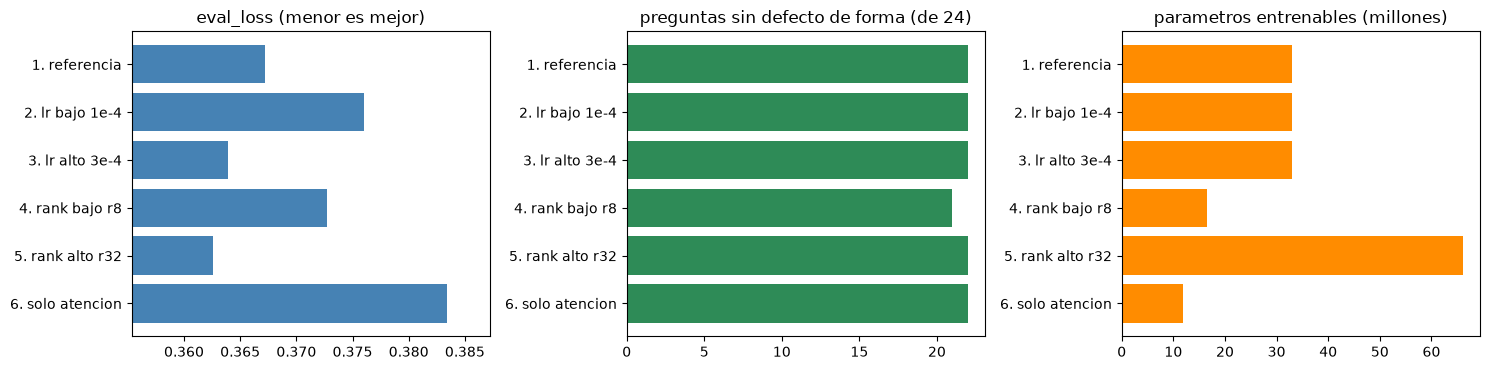

In [7]:
import matplotlib.pyplot as plt

ok = barrido[barrido["eval_loss"].notna()].copy() if "eval_loss" in barrido else pd.DataFrame()
if len(ok):
    ok["limpias"] = ok["estructura"] - ok["parecidas"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    ax[0].barh(ok["configuracion"], ok["eval_loss"], color="steelblue")
    ax[0].set_xlim(ok["eval_loss"].min() * 0.98, ok["eval_loss"].max() * 1.01)
    ax[0].set_title("eval_loss (menor es mejor)")
    ax[1].barh(ok["configuracion"], ok["limpias"], color="seagreen")
    ax[1].set_title(f"preguntas sin defecto de forma (de {N_GEN})")
    ax[2].barh(ok["configuracion"], ok["entrenables_M"], color="darkorange")
    ax[2].set_title("parametros entrenables (millones)")
    for a in ax: a.invert_yaxis()
    plt.tight_layout(); plt.show()

## 3. Seleccion de la configuracion ganadora

El criterio, en este orden:

1. **Preguntas sin defecto de forma** sobre los casos de test. Es lo que el
   usuario final percibe.
2. **`eval_loss`** como desempate, porque el rango entre configuraciones suele
   ser estrecho y la muestra de generacion es pequena.
3. **Parametros entrenables** como tercer desempate: a igualdad de resultado, el
   adaptador mas chico entrena mas rapido y ocupa menos.

Se reporta tambien la dispersion: si todas las configuraciones quedan dentro de
un margen minimo, conviene decirlo en vez de fingir que una es claramente
superior.

In [8]:
if len(ok):
    ok = ok.sort_values(["limpias", "eval_loss", "entrenables_M"],
                        ascending=[False, True, True]).reset_index(drop=True)
    print(ok[["configuracion", "limpias", "eval_loss", "entrenables_M", "pico_GB"]].to_string(index=False))
    print()
    rango = ok["eval_loss"].max() - ok["eval_loss"].min()
    print(f"dispersion de eval_loss entre configuraciones: {rango:.4f}")
    if rango < 0.03:
        print("  -> es un rango estrecho: ninguna configuracion domina claramente por la perdida")

    nombre_ganadora = ok.iloc[0]["configuracion"]
    GANADORA = next(c for c in CONFIGS if c["n"] == nombre_ganadora)
else:
    print("el barrido no dejo resultados validos; se usa la referencia")
    GANADORA = next(c for c in CONFIGS if c["n"].startswith("1."))

print()
print("GANADORA:", GANADORA["n"])
print(f"  r={GANADORA['r']}  alpha={GANADORA['alpha']}  lr={GANADORA['lr']}")
print(f"  modulos: {', '.join(GANADORA['mods'])}")

   configuracion  limpias  eval_loss  entrenables_M  pico_GB
5. rank alto r32       22     0.3626           66.1    10.43
 3. lr alto 3e-4       22     0.3639           33.0     9.87
   1. referencia       22     0.3672           33.0     9.87
 2. lr bajo 1e-4       22     0.3760           33.0     9.87
6. solo atencion       22     0.3834           11.8     9.59
 4. rank bajo r8       21     0.3727           16.5     9.65

dispersion de eval_loss entre configuraciones: 0.0208
  -> es un rango estrecho: ninguna configuracion domina claramente por la perdida

GANADORA: 5. rank alto r32
  r=32  alpha=64  lr=0.0002
  modulos: q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj


## 4. Entrenamiento final: 2 epocas

**Dos epocas, no tres**, y la razon esta medida. En una corrida previa de 3
epocas la perdida de validacion toco su minimo en la epoca 1.89 y despues
**empeoro**: de 0.3545 a 0.3930, quedando peor que en la epoca 1. La tercera
epoca fue contraproducente.

La firma del sobreajuste se ve en la brecha entre las dos perdidas:

| Epoca | eval_loss | train_loss | brecha |
|---|---|---|---|
| 0.95 | 0.3631 | 0.3805 | +0.017 (train mayor, por el dropout) |
| 1.89 | **0.3545** | 0.2614 | -0.093 |
| 3.00 | 0.3930 | 0.1494 | -0.244 |

A partir de la epoca 2 el train sigue cayendo porque el modelo **reconoce**
ejemplos que ya vio, mientras el eval sube: memoriza en vez de generalizar.

`load_best_model_at_end=True` protege el resultado igual —recupera el mejor
checkpoint aunque se entrene de mas— pero entrenar la tercera epoca es gastar
GPU para tirarla.

checkpoint completo en ..\checkpoints: se reanuda (no reentrena)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

{'train_runtime': '0', 'train_loss': '0', 'epoch': '2'}

reanudado; el entrenamiento original tomo 48 min en la RTX 5070 Ti


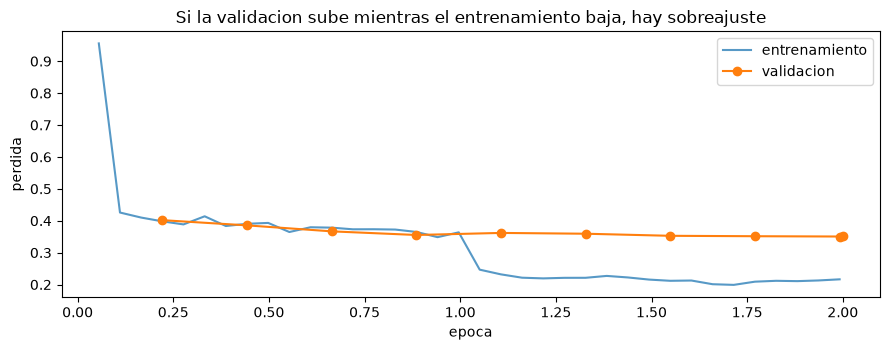

mejor eval_loss: 0.3506 en la epoca 1.99
checkpoint conservado: ..\checkpoints\checkpoint-900


In [9]:
EPOCAS = 1 if PRUEBA else 2
CKPTS = SALIDA.parent.parent / "checkpoints"

# Si una corrida anterior ya completo las epocas, se reanuda desde su checkpoint
# en vez de repetir 48 minutos de calculo identico. Los numeros que se grafican
# abajo son los de aquella corrida, leidos de su registro: no se re-estiman.
completo = False
if CKPTS.exists():
    for d in CKPTS.glob("checkpoint-*"):
        est = d / "trainer_state.json"
        if est.exists() and json.load(open(est))["epoch"] >= EPOCAS:
            completo = True
if completo:
    print(f"checkpoint completo en {CKPTS}: se reanuda (no reentrena)")

t0 = time.time()
model, trainer = entrenar(GANADORA, pasos=None, epocas=EPOCAS,
                          salida=str(CKPTS), evaluar_cada=5 if PRUEBA else 100,
                          reanudar=completo)
if completo:
    print(); print("reanudado; el entrenamiento original tomo 48 min en la RTX 5070 Ti")
else:
    print(); print(f"entrenado en {(time.time()-t0)/60:.1f} min")
    print(f"memoria pico: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

log = pd.DataFrame(trainer.state.log_history)
tr = log[log["loss"].notna()] if "loss" in log else pd.DataFrame()
ev = log[log["eval_loss"].notna()] if "eval_loss" in log else pd.DataFrame()

fig, ax = plt.subplots(figsize=(9, 3.6))
if len(tr): ax.plot(tr["epoch"], tr["loss"], label="entrenamiento", alpha=0.75)
if len(ev): ax.plot(ev["epoch"], ev["eval_loss"], label="validacion", marker="o")
ax.set_xlabel("epoca"); ax.set_ylabel("perdida"); ax.legend()
ax.set_title("Si la validacion sube mientras el entrenamiento baja, hay sobreajuste")
plt.tight_layout(); plt.show()

if len(ev):
    mejor = ev.loc[ev["eval_loss"].idxmin()]
    print(f"mejor eval_loss: {mejor['eval_loss']:.4f} en la epoca {mejor['epoch']:.2f}")
    print(f"checkpoint conservado: {trainer.state.best_model_checkpoint}")


## 5. Base con few-shot contra afinado

`disable_adapter()` apaga el LoRA temporalmente: no hace falta cargar dos modelos
de 8 GB. Es el mismo mecanismo que usa el panel de la aplicacion.

El modelo base recibe **few-shot** -tres ejemplos completos en el prompt- porque
sin ellos no sabria que formato producir y la comparacion seria injusta. Y esa es
justamente una de las metricas: **cuantos tokens de prompt necesita cada uno**.

In [10]:
N_EVAL = 8 if PRUEBA else 60
EJEMPLOS_FS = 3
model.eval()
ejemplos = train_df.sample(EJEMPLOS_FS, random_state=SEMILLA)
casos_eval = test_df.sample(N_EVAL, random_state=SEMILLA)


def prompt_fewshot(fragmento):
    msgs = [{"role": "system", "content": INSTRUCCION}]
    for _, e in ejemplos.iterrows():
        msgs.append({"role": "user", "content": "FRAGMENTO:\n" + e["chunk_text"]})
        msgs.append({"role": "assistant", "content": json.dumps({
            "apto": True, "pregunta": e["pregunta"], "correcta": e["correcta"],
            "incorrectas": list(e["incorrectas"]), "dificultad": e["dificultad"]},
            ensure_ascii=False)})
    msgs.append({"role": "user", "content": "FRAGMENTO:\n" + fragmento})
    return msgs


def generar_uno(msgs, max_new=300):
    texto = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    ids = tok([texto], return_tensors="pt").to(model.device)
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**ids, max_new_tokens=max_new, do_sample=False,
                             pad_token_id=tok.pad_token_id)
    return {"texto": tok.decode(out[0][ids.input_ids.shape[1]:], skip_special_tokens=True).strip(),
            "tok_prompt": ids.input_ids.shape[1], "segundos": time.time() - t0}


resultados_eval = {"base": [], "afinado": []}
for i, (_, fila) in enumerate(casos_eval.iterrows(), 1):
    with model.disable_adapter():
        resultados_eval["base"].append(generar_uno(prompt_fewshot(fila["chunk_text"])))
    resultados_eval["afinado"].append(generar_uno(
        [{"role": "system", "content": INSTRUCCION},
         {"role": "user", "content": "FRAGMENTO:\n" + fila["chunk_text"]}]))
    if i % 20 == 0: print(f"  {i}/{N_EVAL}", flush=True)
print("listo")

  20/60


  40/60


  60/60


listo


In [11]:
def estructura_ok(d):
    return bool(d and d.get("pregunta") and d.get("correcta")
                and isinstance(d.get("incorrectas"), list) and len(d["incorrectas"]) == 3)

filas = []
for etiqueta in ("base", "afinado"):
    rs = resultados_eval[etiqueta]
    ds_ = [parsear(r["texto"]) for r in rs]
    val = [d for d in ds_ if estructura_ok(d)]
    def parecidas_(d):
        ops = [str(d["correcta"])] + [str(x) for x in d["incorrectas"]]
        return any(len(palabras(ops[i]) & palabras(ops[j])) /
                   max(len(palabras(ops[i]) | palabras(ops[j])), 1) > 0.5
                   for i in range(4) for j in range(i + 1, 4))
    filas.append({
        "modelo": etiqueta,
        "JSON valido": f"{sum(d is not None for d in ds_)}/{len(rs)}",
        "estructura completa": f"{len(val)}/{len(rs)}",
        "opciones parecidas": f"{sum(parecidas_(d) for d in val)}/{max(len(val),1)}",
        "tokens de prompt": round(sum(r["tok_prompt"] for r in rs) / len(rs)),
        "segundos": round(sum(r["segundos"] for r in rs) / len(rs), 2),
    })
comparacion = pd.DataFrame(filas).set_index("modelo")
print(comparacion.T.to_string())

modelo                base afinado
JSON valido          60/60   60/60
estructura completa  57/60   60/60
opciones parecidas    3/57    3/60
tokens de prompt       693     135
segundos              4.46    6.61


La metrica de **tokens de prompt** es la ventaja mas solida, y no depende del
criterio de nadie: el base necesita tres ejemplos completos en el prompt y el
afinado se apana con la instruccion. Menos tokens es menos contexto y menos
tiempo por pregunta.

Aviso registrado desde la prueba de humo: el modelo base **ya producia JSON
valido sin few-shot**, asi que esa metrica puede empatar. Si empata, el panel de
la aplicacion debe apoyarse en las demas.

In [12]:
# Las generaciones a disco: revisarlas a mano es parte de la evaluacion y
# volver a generarlas cuesta otra pasada de GPU.
SALIDA.mkdir(parents=True, exist_ok=True)
detalle = []
for i, (_, fila) in enumerate(casos_eval.iterrows()):
    detalle.append({
        "tema": fila["question_focus"], "tipo": fila["question_type"],
        "url": fila["document_url"], "fragmento": fila["chunk_text"],
        "base": parsear(resultados_eval["base"][i]["texto"]),
        "afinado": parsear(resultados_eval["afinado"][i]["texto"]),
    })
json.dump(detalle, open(SALIDA / "generaciones_evaluacion.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=1)
print(f"guardadas {len(detalle)} generaciones para revisar")

for d in detalle[:3]:
    print("\n" + "=" * 92)
    print("TEMA:", d["tema"])
    for quien in ("base", "afinado"):
        q = d[quien]
        print(f"  --- {quien}")
        if estructura_ok(q):
            print("   ", q["pregunta"])
            print("    V", q["correcta"])
            for x in q["incorrectas"]: print("    x", x)
        elif q:
            print("    (JSON incompleto):", str(q)[:110])
        else:
            print("    (no parseable)")

guardadas 60 generaciones para revisar

TEMA: Lennox-Gastaut syndrome
  --- base
    ¿Qué tipo de episodios se asocian comúnmente con el síndrome de Lennox-Gastaut?
    V Ataques de ausencia atípicos y caídas súbitas por pérdida de tono muscular.
    x Episodios de convulsiones prolongadas con pérdida total de conciencia.
    x Convulsiones generalizadas con aumento de temperatura corporal.
    x Episodios de dolor crónico en el sistema nervioso.
  --- afinado
    ¿Cuál de las siguientes afirmaciones es cierta sobre el síndrome de Lennox-Gastaut?
    V Las convulsiones son generalmente muy breves.
    x Los ataques de caída son comunes en todos los pacientes.
    x Las convulsiones son siempre prolongadas y severas.
    x Los ataques de ausencia son raros en este síndrome.

TEMA: primary macronodular adrenal hyperplasia
  --- base
    ¿Por qué se considera que el trastorno PMAH es heredado de forma autosómica dominante?
    V Porque una copia mutada del gen ARMC5 es suficiente para hac

## 6. Maestro contra alumno: cuanto se pierde al destilar

La pregunta central de una destilacion. El diseno permite una comparacion limpia
porque usa **los mismos fragmentos**: el split de test ya trae la pregunta que
genero el maestro (`gpt-4o-mini`) para cada fragmento, y aqui se compara con la
que produce el alumno sobre ese mismo texto.

Juzga un tercer modelo, **`gpt-4o`**, mas capaz que los dos. Evaluar es mas
dificil que generar, y usar el mismo modelo que genero se autoevaluaria con
indulgencia.

El cuarto criterio -que la pregunta corresponda al tema- salio de leer preguntas
a mano: aparecio una sobre equinococosis que hablaba de cisticercosis, y otra que
traducia *chilblains* (sabanones) como "callosidades". El modelo pequeno sustituye
terminos medicos por otros parecidos, y ninguna metrica de formato lo detecta.

In [13]:
from concurrent.futures import ThreadPoolExecutor, as_completed
try:
    from dotenv import load_dotenv
    load_dotenv("../.env")
except Exception:
    pass
from openai import OpenAI

client = OpenAI()
MODELO_JUEZ = "gpt-4o"
N_JUEZ = 6 if PRUEBA else 150

JUEZ = """Eres un revisor de examenes de medicina. Recibes un FRAGMENTO, el TEMA
al que pertenece, y una PREGUNTA de opcion multiple construida a partir de el.

Evalua con severidad:
1. respaldo: la opcion correcta esta afirmada explicitamente en el fragmento?
2. distractor_verdadero: alguna incorrecta es TAMBIEN cierta segun el fragmento?
3. unica_respuesta: hay exactamente una respuesta defendible?
4. tema_correcto: la pregunta se refiere al TEMA indicado y no a otra enfermedad?

Responde SOLO con JSON:
{"respaldo": true/false, "distractor_verdadero": true/false,
 "unica_respuesta": true/false, "tema_correcto": true/false,
 "comentario": "una frase solo si algo falla"}"""

casos_juez = test_df.sample(min(N_JUEZ, len(test_df)), random_state=13).reset_index(drop=True)
print(f"generando {len(casos_juez)} preguntas del alumno...", flush=True)
salidas_alumno, _ = generar_lotes(model, casos_juez["chunk_text"].tolist())
print("listo")

generando 150 preguntas del alumno...


listo


In [14]:
def juzgar(args):
    idx, quien, fila, d = args
    if not estructura_ok(d):
        return idx, quien, None
    texto = (f"TEMA: {fila['question_focus']}\n\nFRAGMENTO:\n{fila['chunk_text']}\n\n"
             f"PREGUNTA: {d['pregunta']}\nCORRECTA: {d['correcta']}\n"
             + "\n".join(f"INCORRECTA: {x}" for x in d["incorrectas"]))
    for intento in range(3):
        try:
            r = client.chat.completions.create(
                model=MODELO_JUEZ, temperature=0,
                messages=[{"role": "system", "content": JUEZ},
                          {"role": "user", "content": texto}])
            return idx, quien, parsear(r.choices[0].message.content)
        except Exception:
            time.sleep(2 * (intento + 1))
    return idx, quien, None


tareas = []
for i, fila in casos_juez.iterrows():
    tareas.append((i, "maestro", fila, {"pregunta": fila["pregunta"],
                                        "correcta": fila["correcta"],
                                        "incorrectas": list(fila["incorrectas"])}))
    tareas.append((i, "alumno", fila, parsear(salidas_alumno[i])))

print(f"juzgando {len(tareas)} preguntas con {MODELO_JUEZ}...", flush=True)
veredictos = {"maestro": {}, "alumno": {}}
with ThreadPoolExecutor(8) as pool:
    for fut in as_completed([pool.submit(juzgar, t) for t in tareas]):
        idx, quien, v = fut.result()
        veredictos[quien][idx] = v

filas = []
for quien, etiqueta in (("maestro", "maestro (gpt-4o-mini)"), ("alumno", "alumno (Qwen afinado)")):
    vs = [v for v in veredictos[quien].values() if v]
    n = max(len(vs), 1)
    limpias = sum(1 for v in vs if v.get("respaldo") and not v.get("distractor_verdadero")
                  and v.get("unica_respuesta") and v.get("tema_correcto"))
    filas.append({"modelo": etiqueta, "evaluadas": len(vs),
                  "correcta respaldada": f"{sum(v.get('respaldo', False) for v in vs)/n*100:.1f}%",
                  "sin distractor cierto": f"{sum(not v.get('distractor_verdadero', True) for v in vs)/n*100:.1f}%",
                  "una sola respuesta": f"{sum(v.get('unica_respuesta', False) for v in vs)/n*100:.1f}%",
                  "tema correcto": f"{sum(v.get('tema_correcto', False) for v in vs)/n*100:.1f}%",
                  "SIN NINGUN DEFECTO": f"{limpias/n*100:.1f}%"})

maestro_alumno = pd.DataFrame(filas).set_index("modelo")
print("\n" + "=" * 88)
print(maestro_alumno.T.to_string())
maestro_alumno.to_csv(DATA / "maestro_vs_alumno.csv")

juzgando 300 preguntas con gpt-4o...



modelo                maestro (gpt-4o-mini) alumno (Qwen afinado)
evaluadas                               145                   139
correcta respaldada                   97.2%                 97.1%
sin distractor cierto                 97.2%                 95.7%
una sola respuesta                    96.6%                 94.2%
tema correcto                         83.4%                 82.7%
SIN NINGUN DEFECTO                    79.3%                 78.4%


### Como leer esta tabla

La brecha entre maestro y alumno **es el costo de la autonomia**: cuanto se
pierde a cambio de que el modelo corra local, sin API y sin costo por consulta.
No es un fallo del proyecto, es su precio, y conviene tenerlo medido en vez de
suponerlo.

Lo que **no** se puede afirmar es que el alumno sea mejor que `gpt-4o-mini`. No
lo es y no se midio contra el en ninguna dimension donde pudiera ganar.

## 7. Guardar el adaptador y las metricas

In [15]:
model.save_pretrained(SALIDA)
tok.save_pretrained(SALIDA)
peso = sum(f.stat().st_size for f in SALIDA.rglob("*") if f.is_file())
print(f"adaptador en {SALIDA}/  ({peso/1e6:.0f} MB)")
for f in sorted(SALIDA.iterdir()):
    print("  ", f.name)

metricas = {
    "modelo_base": MODELO,
    "configuracion": {k: (v if k != "mods" else list(v)) for k, v in GANADORA.items()},
    "epocas": EPOCAS,
    "ejemplos_entrenamiento": len(ds_train),
    "mejor_eval_loss": float(ev["eval_loss"].min()) if len(ev) else None,
    "barrido": barrido.to_dict(orient="records"),
    "base_vs_afinado": comparacion.to_dict(),
    "maestro_vs_alumno": maestro_alumno.to_dict(),
}
json.dump(metricas, open(SALIDA / "metricas_evaluacion.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=1)
print("\nmetricas_evaluacion.json guardado: lo lee el panel de la aplicacion")

if EN_COLAB:
    !cd /content && zip -qr adapter.zip adapter
    print("descarga adapter.zip y descomprimelo junto a app.py")

adaptador en ..\app\adapter/  (276 MB)
   adapter_config.json
   adapter_model.safetensors
   chat_template.jinja
   generaciones_evaluacion.json
   README.md
   tokenizer.json
   tokenizer_config.json

metricas_evaluacion.json guardado: lo lee el panel de la aplicacion


## Estado

| Archivo | Para que |
|---|---|
| `adapter/` | lo carga la aplicacion junto al modelo base |
| `adapter/metricas_evaluacion.json` | alimenta el panel "bajo el capo" |
| `adapter/generaciones_evaluacion.json` | las preguntas generadas, para revisar a mano |
| `data/barrido_hiperparametros.csv` | los resultados de las 6 configuraciones |
| `data/maestro_vs_alumno.csv` | el costo medido de la destilacion |

Siguiente: la aplicacion Streamlit.